**Un dron mide su altitud con un sensor ruidoso. Queremos recuperar la trayectoria suave real $f(t) = \sin(t)$ a partir de mediciones ruidosas.**

### **3.1. Generación del Modelo Estócastico**
¿Que quiere decir esto? es la generación del modelo de la función pero simulando el ruido tal como se dice en el enunciado con una distribución Normal con media cero y varianza $σ^2$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42) #Para que el ejercicio sea reproducible y los análisis no cambien cada que se corre el código

Entonces se evaluan 15 punto equiespaciados en [0, 2pi], con $σ$ = 0.25 en la siguiente función:

**Modelo generador de datos:**
$y_i = f(t_i) + \varepsilon_i$

$y_i = \sin(t_i) + \varepsilon_i$  

 sabiendo que:  $\quad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ 

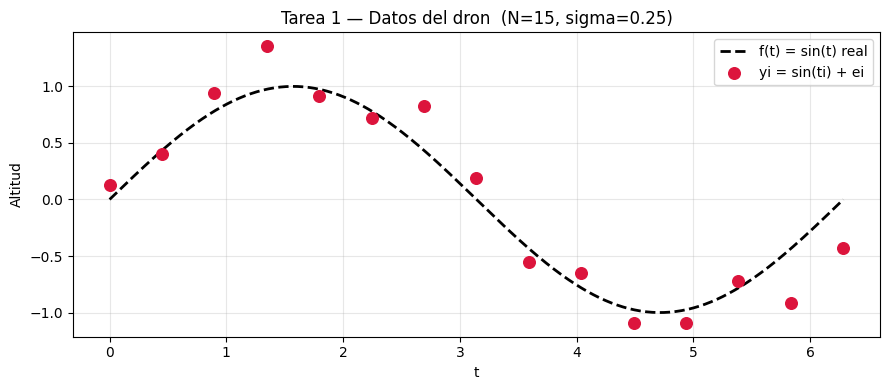

In [3]:
N     = 15
sigma = 0.25
d     = 9

t = np.linspace(0, 2 * np.pi, N)
y = np.sin(t) + np.random.normal(0, sigma, N)

t_plot = np.linspace(0, 2 * np.pi, 500)
f_real = np.sin(t_plot)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_plot, f_real, "k--", lw=2, label="f(t) = sin(t) real")
ax.scatter(t, y, color="crimson", s=70, zorder=5, label="yi = sin(ti) + ei")
ax.set_xlabel("t"); ax.set_ylabel("Altitud")
ax.set_title(f"Tarea 1 — Datos del dron  (N={N}, sigma={sigma})")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### **3.2. Solución del problema de óptimización**

Para la solución tenemos lo siguiente:

**Modelo polinomial de grado $d$:**
$$\hat{y} = w_0 + w_1 t + w_2 t^2 + \cdots + w_d t^d = \mathbf{x}(t)^\top \mathbf{w}$$

**Función de costo Ridge:** usando la deficinición de la Regresión de Ridge 
$$J(\mathbf{w}) = \sum_{i=1}^N (\hat{y}_i - y_i)^2 + \lambda \|\mathbf{w}\|_2^2 = \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \lambda \|\mathbf{w}\|_2^2$$


Sabemos que X se construye de la siguiente manera:

$$X = \begin{bmatrix} 1 & t_1 & t_1^2 & \dots & t_1^d \\ 1 & t_2 & t_2^2 & \dots & t_2^d \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ 1 & t_{15} & t_{15}^2 & \dots & t_{15}^d \end{bmatrix}$$
Donde X tiene las dimensiones $N \times (d+1)$

Y a esta matriz también se le conoce como **Matriz de Vandermonde**, es un término utilizado en algebra lineal para este tipo de matrices, donde cada columna es una progresión geométrica. Utilizado frercuentemente en la interpolación polinómica.

Como en el ejercicio se especifica que debe ser de grado mayor, seleccionare d=9, lo que lleva a que la dimensión de X es 15x10

In [4]:
# Normalizamos t a [0,1] para evitar overflow numerico
# t^9 con t hasta 2*pi ~ 6.28 da t^9 ~ 10^7, lo que explota el gradiente
t_norm      = t / (2 * np.pi)
t_plot_norm = t_plot / (2 * np.pi)

# Matriz de diseño X: columna j = t_norm^j  (shape: 15 x 10)
X      = np.column_stack([t_norm**j      for j in range(d + 1)])
X_plot = np.column_stack([t_plot_norm**j for j in range(d + 1)])

print(f"Forma de X: {X.shape}")

Forma de X: (15, 10)


Ahora, vamos a hallar los valores de $w$, primero con la **solución analítica cerrada** y luego con **descenso del gradiente**:

In [6]:
#Funciones apra usar en otras celdas

#Analitica: Solucion cerrada de Ridge Regression
def ridge_analitica(X, y, lam):
    
    # w* = (X'X + lambda*I)^{-1} X'y
    A = X.T @ X + lam * np.eye(X.shape[1])
    b = X.T @ y
    return np.linalg.solve(A, b)  


#Solcion por gradiente descendente: w = w - eta * gradiente
def ridge_gradiente(X, y, lam, eta, n_iter=20000):
    w      = np.zeros(X.shape[1])
    costos = []
    for _ in range(n_iter):
        residuo = X @ w - y
        grad    = 2 * X.T @ residuo + 2 * lam * w
        w       = w - eta * grad
        costos.append(float(residuo @ residuo + lam * (w @ w)))
    return w, costos


Ahora evaluamos las funciones para comparar:

In [7]:
# Calibracion del learning rate optimo
# La teoria garantiza convergencia si eta < 1 / (2 * lambda_max(X'X + lambda*I))
lam_demo = 0.1
eigvals  = np.linalg.eigvalsh(X.T @ X)
eta_opt  = 0.9 / (2 * (eigvals.max() + lam_demo))
print(f"Learning rate optimo: {eta_opt:.4e}")

# Resolver con ambos metodos
w_analitico          = ridge_analitica(X, y, lam_demo)
w_gd, costos         = ridge_gradiente(X, y, lam_demo, eta=eta_opt)

print(f"\n--- Comparacion con lambda={lam_demo} ---")
print(f"Analitica:  ||w|| = {np.linalg.norm(w_analitico):.4f}")
print(f"Gradiente:  ||w|| = {np.linalg.norm(w_gd):.4f}")
print(f"Diferencia: {np.linalg.norm(w_analitico - w_gd):.2e}")

Learning rate optimo: 1.5554e-02

--- Comparacion con lambda=0.1 ---
Analitica:  ||w|| = 2.5991
Gradiente:  ||w|| = 2.5991
Diferencia: 4.82e-14


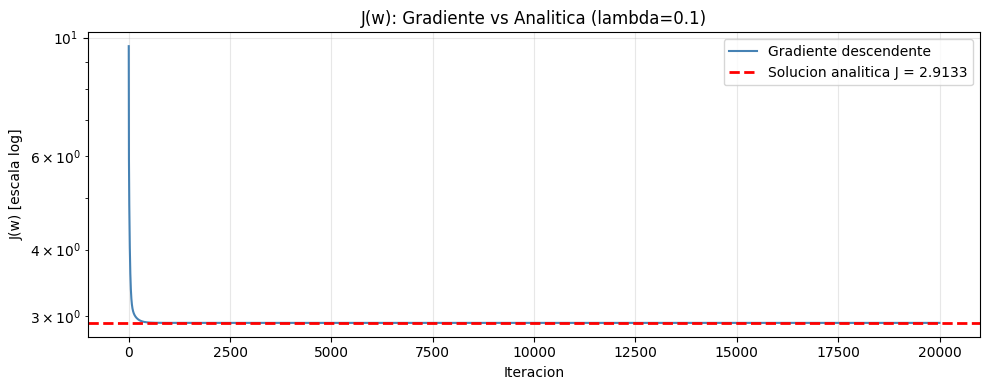

In [10]:
# Calcular J(w) para la solucion analitica (un solo punto)
residuo_a  = X @ w_analitico - y
J_analitica = float(residuo_a @ residuo_a + lam_demo * (w_analitico @ w_analitico))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(costos, color='steelblue', lw=1.5, label='Gradiente descendente')
ax.axhline(J_analitica, color='red', linestyle='--', lw=2,
           label=f'Solucion analitica J = {J_analitica:.4f}')
ax.set_yscale('log')
ax.set_xlabel('Iteracion')
ax.set_ylabel('J(w) [escala log]')
ax.set_title(f'J(w): Gradiente vs Analitica (lambda={lam_demo})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Conclusiones:**  
Ambos métodos convergen al mismo vector de pesos $w$, con una mínima diferencia de $4.82x10^{-14}$. de la función de costo J(w) poemos ver que es una función convexa, y tiene un único mínimo global.

Y en cuando a la comparación de ambos métodos para aprender un poco más de ellos no solo para este ejercicio sino para futuros ejercicios donde los datasets sean mayores:

| | Solución Analítica | Descenso del Gradiente |
|--|--|--|
| **Cómo funciona** | Invierte (X'X + λI) en 1 paso | Itera 20000 veces actualizando w |
| **Costo computacional** | O(d³) — depende del grado | O(N·d) por iteración — depende de los datos |
| **Con N=15 (este ejercicio)** | Ideal, rapidísimo | También funciona bien |
| **Con N=1.000.000** | Invertir matriz enorme, es costoso computacionalmente | Cada iteración sigue siendo barata |
| **Necesita calibrar η** | No | Sí, si la elección de η es mala, diverge o va lento |

Concluyendo, para este ejercicio ambos métodos son válidos y sencillos de calcular, sin embargo para datasets más grandes, el descenso del gradiente es el estandar.

### **3.3. El Efecto de Lambda (Experimento Visual)**

Sabiendo que $\lambda$ es el hiperparámetro de regularización. Controla cuánto penalizamos los pesos grandes en la función de costo:

$J(w) = ||Xw - y||² + λ||w||²$


El $\lambda$ se elige de acuerdo a que tan suave se quiere la curva:

- λ pequeño → pesos libres → curva flexible (riesgo de sobreajuste). Un λ pequeño implica inestabilidas.
- λ grande → pesos pequeños → curva más plana (riesgo de subajuste)

In [11]:
escenarios = {
    'A: lambda=0   (sin regularizacion)': 0.0,
    'B1: lambda=0.001':                   0.001,
    'B2: lambda=0.1':                     0.1,
    'B3: lambda=1.0':                     1.0,
    'C: lambda=1000 (extrema)':           1000.0,
}
colores = ['red', 'darkorange', 'limegreen', 'royalblue', 'purple']
estilos = ['-',   '--',         '--',        '--',        '-.']

pesos = {}
preds = {}

for nombre, lam in escenarios.items():
    w = ridge_analitica(X, y, lam)
    pesos[nombre] = w
    preds[nombre] = X_plot @ w
    print(f'lambda={lam:8.3f}  ->  ||w|| = {np.linalg.norm(w):.3f}')

lambda=   0.000  ->  ||w|| = 55600.193
lambda=   0.001  ->  ||w|| = 17.425
lambda=   0.100  ->  ||w|| = 2.599
lambda=   1.000  ->  ||w|| = 1.104
lambda=1000.000  ->  ||w|| = 0.006


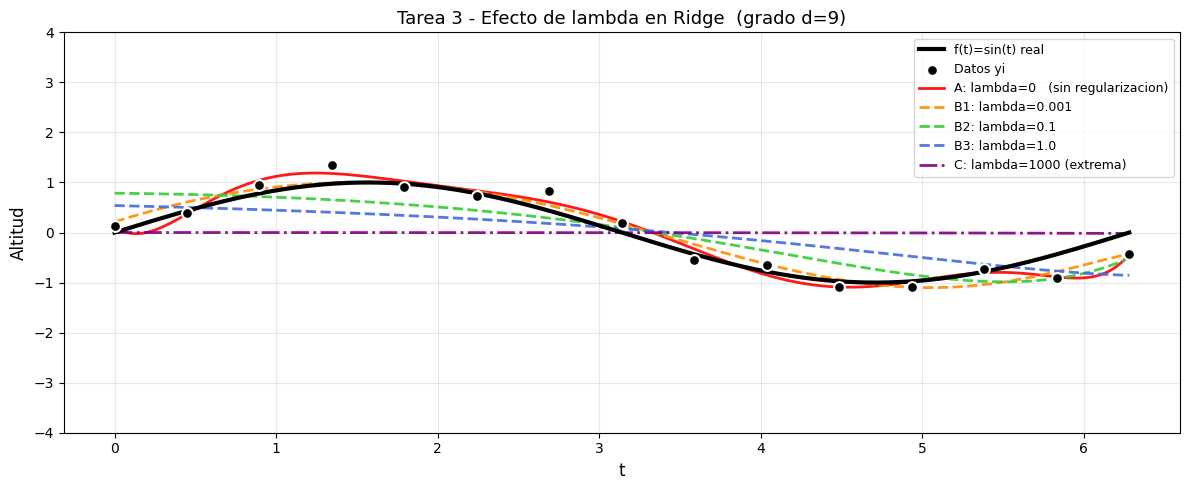

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

# Curva real
ax.plot(t_plot, f_real, 'k-', lw=3, label='f(t)=sin(t) real', zorder=10)

# Datos
ax.scatter(t, y, color='black', s=60, zorder=15,
           edgecolors='white', lw=1.5, label='Datos yi')

# Curva de cada escenario
for (nombre, _), color, estilo in zip(escenarios.items(), colores, estilos):
    ax.plot(t_plot, preds[nombre], color=color,
            linestyle=estilo, lw=2, label=nombre, alpha=0.9)

ax.set_ylim(-4, 4)
ax.set_xlabel('t', fontsize=12)
ax.set_ylabel('Altitud', fontsize=12)
ax.set_title(f'Tarea 3 - Efecto de lambda en Ridge  (grado d={d})', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

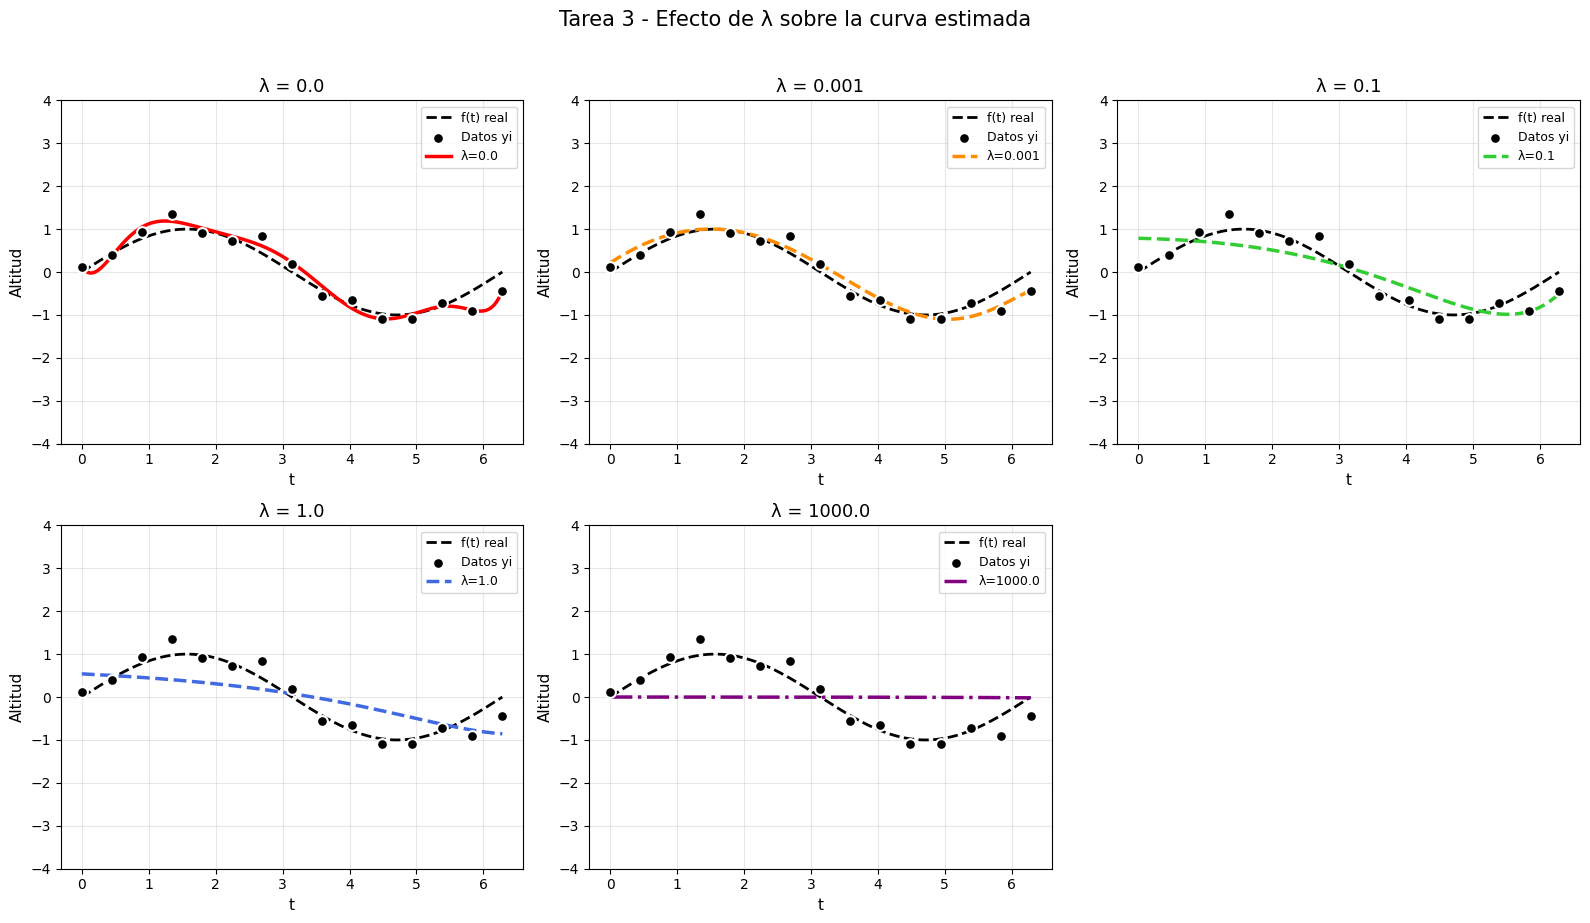

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, ((nombre, lam), color, estilo) in enumerate(zip(escenarios.items(), colores, estilos)):
    ax = axes[i]
    
    # Curva real
    ax.plot(t_plot, f_real, 'k--', lw=2, label='f(t) real')
    
    # Datos
    ax.scatter(t, y, color='black', s=60, zorder=5,
               edgecolors='white', lw=1.5, label='Datos yi')
    
    # Curva estimada
    ax.plot(t_plot, preds[nombre], color=color,
            linestyle=estilo, lw=2.5, label=f'λ={lam}')
    
    ax.set_ylim(-4, 4)
    ax.set_title(f'λ = {lam}', fontsize=13)
    ax.set_xlabel('t', fontsize=11)
    ax.set_ylabel('Altitud', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# Apagar el sexto panel que queda vacio
axes[5].axis('off')

plt.suptitle('Tarea 3 - Efecto de λ sobre la curva estimada', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

**Concluciones:**

Analizando cada caso:


| λ | $‖w‖$ | Interpretación |
| ------------- |:-------------:|:-------------:|
| 0     | 55600    | Los pesos son enormes, el modelo hace lo que sea para pasar por cada punto    |
| 0.001    | 17.4    | Ya baja drásticamente con solo un poco de penalización     |
| 0.1     | 2.6     | Pesos controlados: curva suave    |
| 1.0    | 1.1    | Pesos pequeños: curva empieza a perder forma   |
| 1000    | 0.006    | Pesos casi cero: curva plana     |


Ahora anlizando gráfica por gráfica para encontrar la mejor λ para el modelo:

- **λ=0 (sobreajuste):** La curva sigue muy de cerca cada punto ruidoso.
  Aunque visualmente no se ve tan caótica, los pesos internos son enormes 
  (‖w‖=55600). El modelo está haciendo malabares: algunos coeficientes son 
  locamente positivos y otros locamente negativos para cancelarse entre sí. 
  _Es inestable, si agregáramos un dato nuevo, el modelo cambiaría completamente._

- **λ=0.001:** Reduce los pesos drásticamente (‖w‖=17.4) con solo un poco 
  de penalización. La curva se ajusta bien pero todavía sigue demasiado de 
  cerca los puntos ruidosos.

- **λ=0.1:** Pesos controlados (‖w‖=2.6). La curva suaviza el ruido sin 
  perder la forma general de sin(t). Es el mejor balance entre ajustar 
  los datos e ignorar el ruido.

- **λ=1.0:** La curva empieza a perder la forma de sin(t), especialmente 
  en los extremos. La penalización ya está siendo demasiado agresiva.

- **λ=1000 (subajuste):** Los pesos colapsan casi a cero (‖w‖=0.006). 
  La curva es una línea horizontal — el modelo ignoró completamente 
  los datos. Penalización tan extrema que destruye el modelo.

Entonces, podemos concluir λ=0.1 es el balance óptimo para este problema. Ni memoriza el ruido (λ=0) ni ignora los datos (λ=1000).

### **3.4. Reflexión de Coeficientes**
Para la reflexión de los coeficinetes se realiza un gráfico de barras comparando $∣w_j​∣$ en escala logarítmica entre:

- Escenario A (λ=0)
- Escenario B (El seleccionado es λ=0.1)

¿Por qué escala logaritmica en lugar de escala normal? porque en escala normal las barras de λ=0.1 serían invisibles al lado de las de λ=0. El logaritmo permite ver ambas en la misma gráfica de forma comparable.

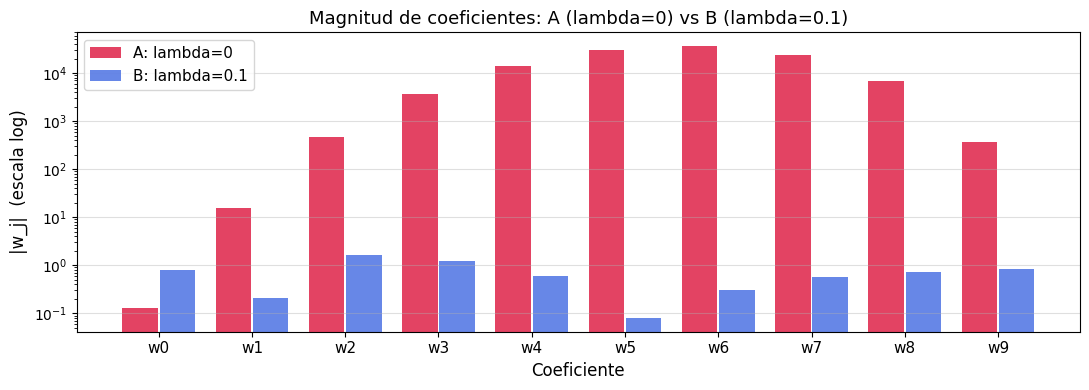

In [ ]:
w_A = pesos['A: lambda=0 ']
w_B = pesos['B2: lambda=0.1']
idx = np.arange(d + 1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(idx - 0.2, np.abs(w_A), 0.38, 
       label='A: lambda=0',   color='crimson',   alpha=0.8)
ax.bar(idx + 0.2, np.abs(w_B), 0.38, 
       label='B: lambda=0.1', color='royalblue', alpha=0.8)

ax.set_yscale('log')
ax.set_xticks(idx)
ax.set_xticklabels([f'w{j}' for j in idx], fontsize=11)
ax.set_xlabel('Coeficiente', fontsize=12)
ax.set_ylabel('|w_j|  (escala log)', fontsize=12)
ax.set_title('Magnitud de coeficientes: A (lambda=0) vs B (lambda=0.1)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

**Conclusiones:**
La gráfica confirma numéricamente lo que vimos en las curvas: con λ=0 los 
coeficientes son enormes (hasta 10^4 en w5 y w6), mientras que con λ=0.1 
todos se mantienen por debajo de 10^0. Esa diferencia de hasta 10.000 veces 
explica por qué la curva roja oscilaba violentamente — internamente el modelo 
estaba haciendo malabares con pesos gigantes que se cancelaban entre sí.

Un detalle revelador es w0: es el único coeficiente donde λ=0 es *menor*
que λ=0.1. Esto ocurre porque con λ=0 el modelo distribuye libremente la 
responsabilidad entre todos los coeficientes, entonces w0 no necesita ser 
grande porque w1, w2...,w9 lo compensan. Con λ=0.1 en cambio, Ridge penaliza 
los coeficientes de las potencias altas (w5, w6...) más agresivamente porque 
son los que generan las oscilaciones, entonces el modelo prefiere apoyarse 
más en w0 para capturar el nivel general de la curva.

En resumen: Ridge no encoge todos los pesos por igual, sino que 
redistribuye cómo el modelo usa cada coeficiente, favoreciendo los 
términos simples sobre las potencias altas que generan inestabilidad.